In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.colors import LogNorm 

In [7]:
y3data_old = fits.open('../data/dv/real_map3_desy3_blind.fits')
y3data_old.info()

mycov = fits.open('../data/covariance/xip_xim_map3_covariance_8ARCMINCUT_31Oct24.fits')
mycov.info()

y3data_new = np.load("../data/dv/Y3blind_concatenated_map3_december_8arcmincut/map3_concatenated_Y3_blind_8arcmincut_DECEMBER.npy")

Filename: ../data/dv/real_map3_desy3_blind.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
Filename: ../data/covariance/xip_xim_map3_covariance_8ARCMINCUT_31Oct24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   


In [17]:
print(y3data_new)

[1.09537425e-09 3.39625654e-10 1.32816853e-10 3.39463914e-12
 1.20251797e-09 2.81102676e-10 9.65202779e-11 6.75979584e-12
 1.60628684e-09 4.91501209e-10 1.23131189e-10 1.08005390e-11
 1.97282612e-09 6.09480914e-10 1.32462898e-10 1.57202211e-11
 1.11201266e-09 2.82691637e-10 4.55105156e-11 1.01435305e-11
 1.53907425e-09 6.43057895e-10 1.14293779e-10 1.27875046e-11
 1.05908292e-09 6.95646309e-10 1.42787295e-10 1.70993285e-11
 1.19811353e-09 4.84370750e-10 1.83985825e-10 1.92830443e-11
 1.55205078e-09 1.07428011e-09 2.30001214e-10 2.85609926e-11
 2.92501230e-09 1.53116748e-09 2.77482070e-10 4.31993840e-11
 9.07759230e-10 3.35921688e-10 1.52202656e-10 1.29311341e-11
 2.13052068e-09 8.14488826e-10 2.18216911e-10 2.26593153e-11
 3.26079226e-09 1.10274209e-09 2.19172880e-10 2.32793190e-11
 2.68576160e-09 1.02296309e-09 2.95438664e-10 4.13792256e-11
 2.92107855e-09 1.51636267e-09 3.32829061e-10 2.48961823e-11
 2.94084542e-09 1.40944151e-09 3.68643256e-10 2.47009188e-11
 3.63229369e-09 1.584799

In [8]:
map3cutcovmat = mycov[1].data[400:,:][:,400:]

In [13]:
for i in range(80):
    y3data_old[1].data[i][6] = y3data_new[i]
    for j in range(80):
        y3data_old[2].data[i][j] = map3cutcovmat[i][j]

newfits = '../data/dv/real_map3_desy3_blind_DECEMBER_8arcmincut.fits'
y3data_old.writeto(newfits)

In [14]:
testnewfits = fits.open('../data/dv/real_map3_desy3_blind_DECEMBER_8arcmincut.fits')
testnewfits.info()

Filename: ../data/dv/real_map3_desy3_blind_DECEMBER_8arcmincut.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


In [16]:
testnewfits[1].data

FITS_rec([(1, 1, 1,  7.,  7.,  7., 1.09537425e-09),
          (1, 1, 1, 14., 14., 14., 3.39625654e-10),
          (1, 1, 1, 25., 25., 25., 1.32816853e-10),
          (1, 1, 1, 40., 40., 40., 3.39463914e-12),
          (1, 1, 2,  7.,  7.,  7., 1.20251797e-09),
          (1, 1, 2, 14., 14., 14., 2.81102676e-10),
          (1, 1, 2, 25., 25., 25., 9.65202779e-11),
          (1, 1, 2, 40., 40., 40., 6.75979584e-12),
          (1, 1, 3,  7.,  7.,  7., 1.60628684e-09),
          (1, 1, 3, 14., 14., 14., 4.91501209e-10),
          (1, 1, 3, 25., 25., 25., 1.23131189e-10),
          (1, 1, 3, 40., 40., 40., 1.08005390e-11),
          (1, 1, 4,  7.,  7.,  7., 1.97282612e-09),
          (1, 1, 4, 14., 14., 14., 6.09480914e-10),
          (1, 1, 4, 25., 25., 25., 1.32462898e-10),
          (1, 1, 4, 40., 40., 40., 1.57202211e-11),
          (1, 2, 2,  7.,  7.,  7., 1.11201266e-09),
          (1, 2, 2, 14., 14., 14., 2.82691637e-10),
          (1, 2, 2, 25., 25., 25., 4.55105156e-11),
          (1

In [32]:
from astropy.io import fits
filee = fits.open('../data/dv/blind-metacal-2pt-DESY3.fits')
filee[4].data
zval = []
bin1 = []
bin2 = []
bin3 = []
bin4 = []
for i in range(len(filee[4].data)):
    zval.append(filee[4].data[i][0])
    bin1.append(filee[4].data[i][3])
    bin2.append(filee[4].data[i][4])
    bin3.append(filee[4].data[i][5])
    bin4.append(filee[4].data[i][6])

In [17]:
newbin1 = np.load('../data/dv/new_sompz/new_sompz_bin0.npy')
print(len(newbin1))
newbin2 = np.load('../data/dv/new_sompz/new_sompz_bin1.npy')
newbin3 = np.load('../data/dv/new_sompz/new_sompz_bin2.npy')
newbin4 = np.load('../data/dv/new_sompz/new_sompz_bin3.npy')

300


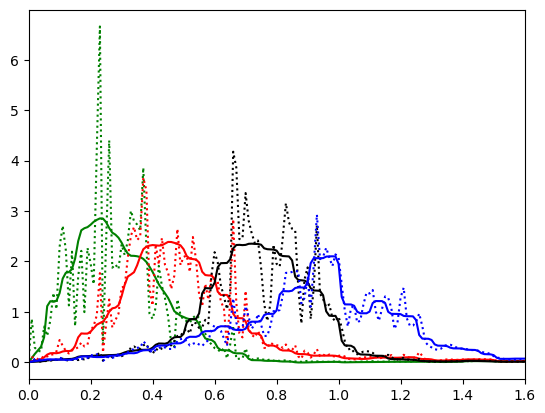

In [25]:
plt.plot(zval, bin1, color='g')
plt.plot(zval[1:], newbin1, color='g', ls=':')
plt.plot(zval, bin2, color='r')
plt.plot(zval[1:], newbin2, color='r', ls=':')
plt.plot(zval, bin3, color='k')
plt.plot(zval[1:], newbin3, color='k', ls=':')
plt.plot(zval, bin4, color='b')
plt.plot(zval[1:], newbin4, color='b', ls=':')
plt.xlim(0,1.6)
plt.savefig("Distributions_old_new.png")

In [26]:
newfitsdv = fits.open('/Users/gchgomes/Downloads/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate_newbins.fits')

In [27]:
newfitsdv.info()

Filename: /Users/gchgomes/Downloads/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate_newbins.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (1000, 1000)   float64   
  2  xip           1 BinTableHDU     37   200R x 8C   [K, K, K, D, D, D, D, D]   
  3  xim           1 BinTableHDU     37   200R x 8C   [K, K, K, D, D, D, D, D]   
  4  gammat        1 BinTableHDU     35   480R x 7C   [K, K, K, D, D, D, D]   
  5  wtheta        1 BinTableHDU     37   120R x 8C   [K, K, K, D, D, D, D, D]   
  6  nz_source     1 BinTableHDU     32   300R x 7C   [D, D, D, D, D, D, D]   
  7  nz_lens       1 BinTableHDU     34   159R x 9C   [D, D, D, D, D, D, D, D, D]   
  8  nz_source_realisation_0    1 BinTableHDU     32   300R x 7C   [D, D, D, D, D, D, D]   
  9  nz_source_realisation_1    1 BinTableHDU     32   300R x 7C   [D, D, D, D, D, D, D]   
 10  nz_source_realisation_2    1 BinTableH

In [35]:
print(newfitsdv[6].data)
zvalnew = []
bin1new = []
bin2new = []
bin3new = []
bin4new = []
for i in range(len(newfitsdv[6].data)):
    zvalnew.append(newfitsdv[6].data[i][0])
    bin1new.append(newfitsdv[6].data[i][3])
    bin2new.append(newfitsdv[6].data[i][4])
    bin3new.append(newfitsdv[6].data[i][5])
    bin4new.append(newfitsdv[6].data[i][6])

[(0.  , 0.005, 0.01,  1.33506324e-05, 1.29577163e-05, 9.22372878e-06, 2.47700337e-05)
 (0.01, 0.015, 0.02,  7.88385496e-04, 1.86298973e-04, 4.15446765e-05, 1.09671067e-04)
 (0.02, 0.025, 0.03,  1.60747682e-03, 2.93654139e-04, 7.36963128e-05, 2.06864612e-04)
 (0.03, 0.035, 0.04,  2.31228476e-03, 4.14433893e-04, 1.10887564e-04, 2.84681704e-04)
 (0.04, 0.045, 0.05,  3.02854909e-03, 5.70222079e-04, 1.46129546e-04, 3.33922643e-04)
 (0.05, 0.055, 0.06,  4.90127071e-03, 9.30710138e-04, 2.20680695e-04, 4.08403264e-04)
 (0.06, 0.065, 0.07,  1.10313013e-02, 1.45886578e-03, 3.32806362e-04, 5.21275106e-04)
 (0.07, 0.075, 0.08,  1.20028115e-02, 1.72738200e-03, 3.94304658e-04, 5.31850148e-04)
 (0.08, 0.085, 0.09,  1.18977542e-02, 1.75310813e-03, 4.29648351e-04, 5.07443018e-04)
 (0.09, 0.095, 0.1 ,  1.21028918e-02, 1.73380139e-03, 4.59344102e-04, 4.89346608e-04)
 (0.1 , 0.105, 0.11,  1.35909373e-02, 1.83972441e-03, 4.93750834e-04, 4.81259458e-04)
 (0.11, 0.115, 0.12,  1.64594429e-02, 2.07213678e-03, 

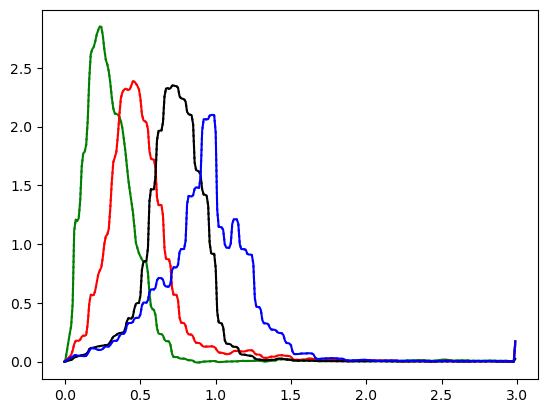

In [40]:
def normalize(bin_vals, z_vals):
    integral = np.trapz(bin_vals, z_vals)
    return bin_vals / integral if integral != 0 else bin_vals

bin1new = normalize(bin1new, zval[1:])
bin2new = normalize(bin2new, zval[1:])
bin3new = normalize(bin3new, zval[1:])
bin4new = normalize(bin4new, zval[1:])

# Plot
plt.plot(zval, bin1, color='g')
plt.plot(zval[1:], bin1new, color='g', ls=':')
plt.plot(zval, bin2, color='r')
plt.plot(zval[1:], bin2new, color='r', ls=':')
plt.plot(zval, bin3, color='k')
plt.plot(zval[1:], bin3new, color='k', ls=':')
plt.plot(zval, bin4, color='b')
plt.plot(zval[1:], bin4new, color='b', ls=':')
plt.show()
#plt.savefig("Distributions_old_new.png")

In [41]:
print(bin1)
print(bin1new)

[0.0, 0.001344475231470018, 0.07939434922075066, 0.16188092827963282, 0.23285860062884015, 0.3049899897998328, 0.4935823914997428, 1.1109070270794628, 1.2087429477923628, 1.1981631520623892, 1.2188215300603333, 1.3686751331235156, 1.6575479456566415, 1.7722140893691627, 1.7865528153111787, 1.8470060594099071, 2.0524658215668308, 2.4013063043177505, 2.6159469898284624, 2.657238181819181, 2.6786225486785757, 2.72620303773942, 2.784628124310714, 2.8229230603519935, 2.8520981307845563, 2.848209266531602, 2.777211977825301, 2.6608685253589206, 2.5693591015269686, 2.5298537833254056, 2.4687810280856963, 2.3715567373650632, 2.2473755349745934, 2.1535096447440734, 2.1106811388238946, 2.1090138390212427, 2.1011181410671322, 2.084195498519385, 2.048686621104446, 1.9872675425435389, 1.8932287868812023, 1.790247643820583, 1.6685886968903318, 1.5446948829697469, 1.4515438167377661, 1.3656119306381609, 1.2735755654028706, 1.1483980880572036, 1.010861956497896, 0.9650361784487627, 0.9221878210292221,

In [45]:
print((bin4[1:]-bin4new)/bin4new)

[-6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06 -6.43555349e-06
 -6.43555349e-06 -6.43555